In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/preranaghosh/dataset-californiahousingdata/housing.csv")

target = 'median_house_value'

features = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'ocean_proximity'
]

print("Target:")
print(target)

print("\nFeatures:")
print(features)

Target:
median_house_value

Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [9]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [10]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)

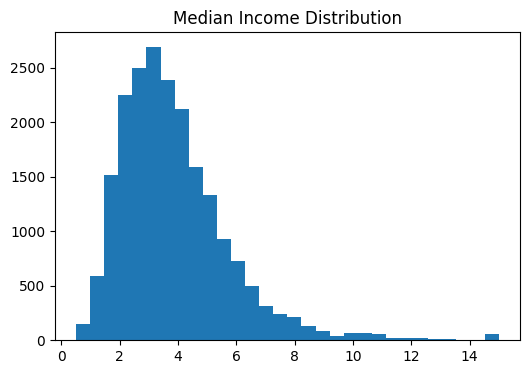

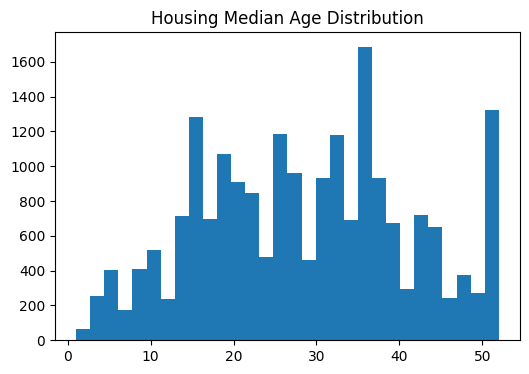

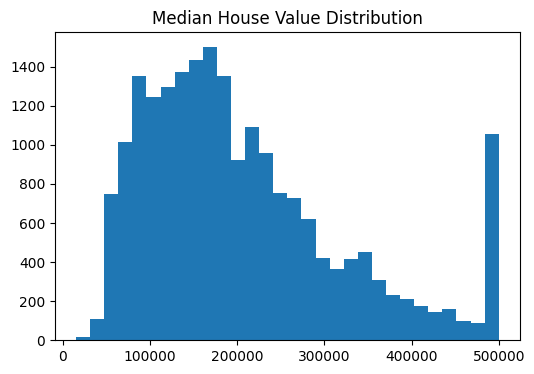

In [11]:
plt.figure(figsize = (6, 4))
plt.hist(df['median_income'], bins = 30)
plt.title("Median Income Distribution")
plt.show()


plt.figure(figsize = (6, 4))
plt.hist(df['housing_median_age'], bins = 30)
plt.title("Housing Median Age Distribution")
plt.show()


plt.figure(figsize = (6, 4))
plt.hist(df['median_house_value'], bins = 30)
plt.title("Median House Value Distribution")
plt.show()

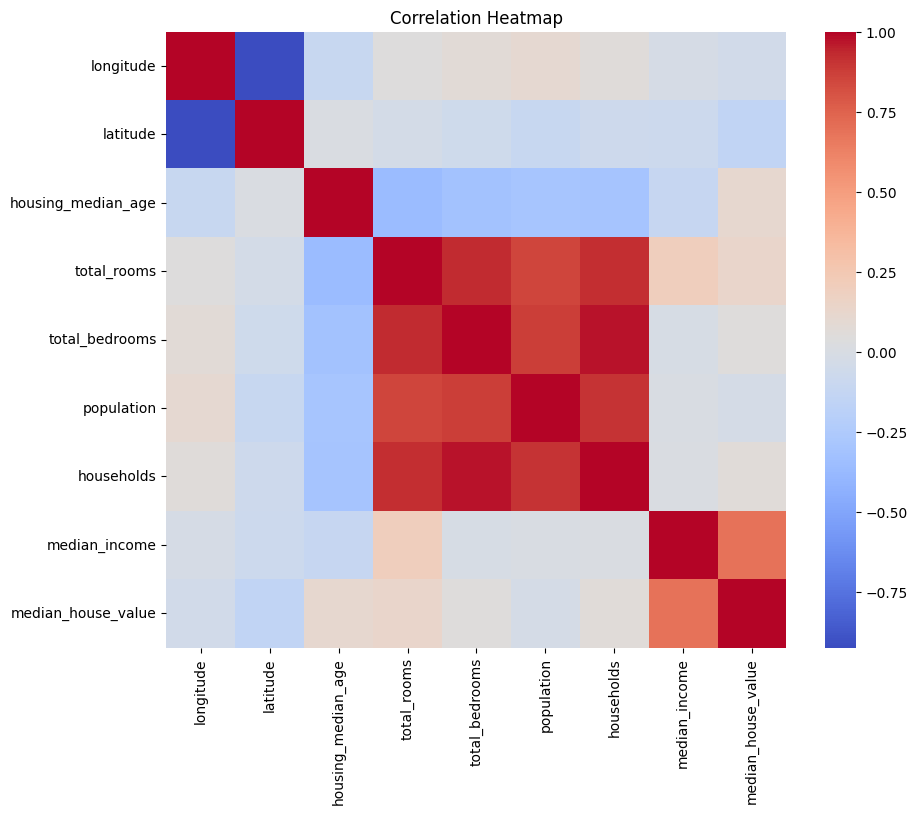

In [12]:
plt.figure(figsize = (10, 8))

sns.heatmap(
    df.corr(numeric_only = True),
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Most useful features:

# median_income:
# Higher income areas generally have more expensive houses.

# latitude and longitude:
# House prices vary strongly by location.

# housing_median_age:
# Age of houses may influence price.

# total_rooms and households:
# Give information about property size and living density.

# ocean_proximity:
# Houses near the ocean are usually more expensive.

In [13]:
df['high_value'] = (
    df['median_house_value']
    >
    df['median_house_value'].median()
).astype(int)

In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)


df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)


median_price = df['median_house_value'].median()

df['high_value'] = (
    df['median_house_value'] > median_price
).astype(int)


X = df.drop(
    columns=[
        'median_house_value',
        'high_value'
    ]
)

y = df['high_value']


X = pd.get_dummies(
    X,
    drop_first=True
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)


pred = model.predict(
    X_test
)


print(
    "Accuracy =",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    "Precision =",
    precision_score(
        y_test,
        pred
    )
)

print(
    "Recall =",
    recall_score(
        y_test,
        pred
    )
)

print(
    "\nConfusion Matrix:\n",
    confusion_matrix(
        y_test,
        pred
    )
)

Accuracy = 0.8328488372093024
Precision = 0.8357178095707942
Recall = 0.825938566552901

Confusion Matrix:
 [[1744  333]
 [ 357 1694]]


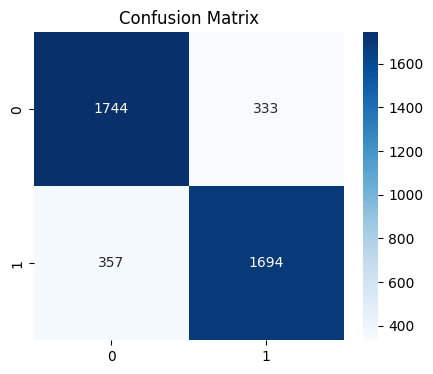

In [17]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize = (5, 4))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.show()